In [1]:
import os
import glob
import pandas as pd

DATA_ROOT = "/scratch/project_2018481/relbouaz/echonet"
VIDEO_DIR = os.path.join(DATA_ROOT, "Videos")
CSV_PATH = os.path.join(DATA_ROOT, "FileList.csv")

print("Checking paths...")
print("CSV exists:", os.path.exists(CSV_PATH))
print("Videos folder exists:", os.path.exists(VIDEO_DIR))

df = pd.read_csv(CSV_PATH)
print("Dataset shape:", df.shape)
display(df.head())

videos = glob.glob(os.path.join(VIDEO_DIR, "*.avi"))
print("Number of videos:", len(videos))
print("First video:", videos[0] if videos else "No videos found")

Checking paths...
CSV exists: True
Videos folder exists: True
Dataset shape: (10030, 9)


,FileName,EF,ESV,EDV,FrameHeight,FrameWidth,FPS,NumberOfFrames,Split
0,0X100009310A3BD7FC,78.498406,14.881368,69.210534,112,112,50,174,VAL
1,0X1002E8FBACD08477,59.101988,40.383876,98.742884,112,112,50,215,TRAIN
2,0X1005D03EED19C65B,62.363798,14.267784,37.909734,112,112,50,104,TRAIN
3,0X10075961BC11C88E,54.545097,33.143084,72.914210,112,112,55,122,TRAIN
4,0X10094BA0A028EAC3,24.887742,127.581945,169.855024,112,112,52,207,VAL


Number of videos: 10030
First video: /scratch/project_2018481/relbouaz/echonet/Videos/0X2C5FA07F95C49BEE.avi


In [2]:
import cv2
import numpy as np
import torch

def read_video_opencv(video_path, num_frames=32, img_size=112, convert_gray_to_rgb=True):
    cap = cv2.VideoCapture(video_path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames <= 0:
        cap.release()
        raise ValueError(f"Could not read frames from {video_path}")

    indices = np.linspace(0, total_frames - 1, num_frames).astype(int)
    current_idx = 0
    target_set = set(indices.tolist())
    grabbed_frames = {}

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if current_idx in target_set:
            frame = cv2.resize(frame, (img_size, img_size))

            if len(frame.shape) == 2:
                if convert_gray_to_rgb:
                    frame = cv2.cvtColor(frame, cv2.COLOR_GRAY2RGB)
            else:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            grabbed_frames[current_idx] = frame

        current_idx += 1

    cap.release()

    frames = []
    for idx in indices:
        if idx in grabbed_frames:
            frames.append(grabbed_frames[idx])
        else:
            raise ValueError(f"Missing sampled frame {idx} in {video_path}")

    video = np.stack(frames)
    video = torch.tensor(video, dtype=torch.float32) / 255.0
    video = video.permute(0, 3, 1, 2)

    return video

In [3]:
sample_video = videos[0]
video = read_video_opencv(sample_video, num_frames=32, img_size=112)

print("Sample video path:", sample_video)
print("Loaded video shape:", video.shape)
print("Min/Max:", video.min().item(), video.max().item())

Sample video path: /scratch/project_2018481/relbouaz/echonet/Videos/0X2C5FA07F95C49BEE.avi
Loaded video shape: torch.Size([32, 3, 112, 112])
Min/Max: 0.0 1.0


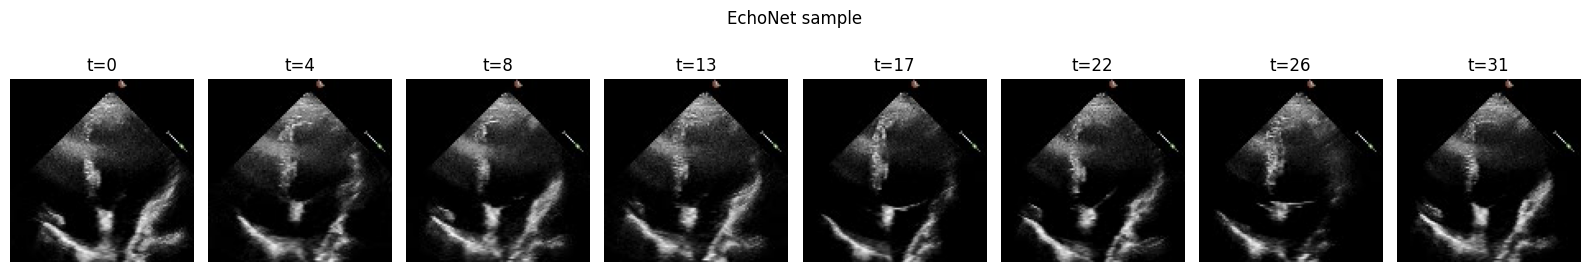

In [4]:
import matplotlib.pyplot as plt

def show_video_frames(video_tensor, n_show=8, title="Sample Video"):
    x = video_tensor.clone()
    x = torch.clamp(x, 0, 1)

    T = x.shape[0]
    indices = np.linspace(0, T - 1, n_show).astype(int)

    plt.figure(figsize=(16, 3))
    for i, idx in enumerate(indices):
        frame = x[idx].permute(1, 2, 0).cpu().numpy()
        plt.subplot(1, n_show, i + 1)
        plt.imshow(frame)
        plt.axis("off")
        plt.title(f"t={idx}")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_video_frames(video, n_show=8, title="EchoNet sample")

In [5]:
from torch.utils.data import Dataset

def normalize_video_tensor(video):
    return (video - 0.5) / 0.5  # [0,1] -> [-1,1]


class EchoVideoDataset(Dataset):
    def __init__(self, df, video_dir, num_frames=32, img_size=112, normalize=True, return_ef=True):
        self.df = df.reset_index(drop=True).copy()
        self.video_dir = video_dir
        self.num_frames = num_frames
        self.img_size = img_size
        self.normalize = normalize
        self.return_ef = return_ef

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        filename = row["FileName"]
        ef = float(row["EF"])
        label = int(ef >= 50.0)  # binary classification threshold

        video_path = os.path.join(self.video_dir, f"{filename}.avi")

        video = read_video_opencv(
            video_path=video_path,
            num_frames=self.num_frames,
            img_size=self.img_size,
            convert_gray_to_rgb=True
        )

        if self.normalize:
            video = normalize_video_tensor(video)

        sample = {
            "video": video,
            "label": torch.tensor(label, dtype=torch.long),
            "filename": filename
        }

        if self.return_ef:
            sample["ef"] = torch.tensor(ef, dtype=torch.float32)

        return sample

In [6]:
dataset = EchoVideoDataset(
    df=df,
    video_dir=VIDEO_DIR,
    num_frames=32,
    img_size=112,
    normalize=True,
    return_ef=True
)

sample = dataset[0]

print("Dataset length:", len(dataset))
print("Filename:", sample["filename"])
print("Video shape:", sample["video"].shape)
print("Label:", sample["label"].item())
print("EF:", sample["ef"].item())
print("Min/Max:", sample["video"].min().item(), sample["video"].max().item())

Dataset length: 10030
Filename: 0X100009310A3BD7FC
Video shape: torch.Size([32, 3, 112, 112])
Label: 1
EF: 78.49840545654297
Min/Max: -1.0 1.0


In [7]:
train_df = df[df["Split"] == "TRAIN"].copy().reset_index(drop=True)
val_df   = df[df["Split"] == "VAL"].copy().reset_index(drop=True)
test_df  = df[df["Split"] == "TEST"].copy().reset_index(drop=True)

print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

print("\nTrain split example:")
display(train_df.head())

Train: 7465
Val  : 1288
Test : 1277

Train split example:


,FileName,EF,ESV,EDV,FrameHeight,FrameWidth,FPS,NumberOfFrames,Split
0,0X1002E8FBACD08477,59.101988,40.383876,98.742884,112,112,50,215,TRAIN
1,0X1005D03EED19C65B,62.363798,14.267784,37.909734,112,112,50,104,TRAIN
2,0X10075961BC11C88E,54.545097,33.143084,72.914210,112,112,55,122,TRAIN
3,0X100E3B8D3280BEC5,36.573739,81.747281,128.885543,112,112,38,101,TRAIN
4,0X100E491B3CD58DE2,33.991745,76.865569,116.448419,112,112,50,226,TRAIN


In [8]:
NUM_FRAMES = 32
IMG_SIZE = 112

train_dataset = EchoVideoDataset(
    df=train_df,
    video_dir=VIDEO_DIR,
    num_frames=NUM_FRAMES,
    img_size=IMG_SIZE,
    normalize=True,
    return_ef=True
)

val_dataset = EchoVideoDataset(
    df=val_df,
    video_dir=VIDEO_DIR,
    num_frames=NUM_FRAMES,
    img_size=IMG_SIZE,
    normalize=True,
    return_ef=True
)

test_dataset = EchoVideoDataset(
    df=test_df,
    video_dir=VIDEO_DIR,
    num_frames=NUM_FRAMES,
    img_size=IMG_SIZE,
    normalize=True,
    return_ef=True
)

print("Datasets created:")
print("Train:", len(train_dataset))
print("Val  :", len(val_dataset))
print("Test :", len(test_dataset))

Datasets created:
Train: 7465
Val  : 1288
Test : 1277


In [9]:
from torch.utils.data import DataLoader

BATCH_SIZE = 8
NUM_WORKERS = 0
PIN_MEMORY = True

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print("Dataloaders ready.")

Dataloaders ready.


In [10]:
batch = next(iter(train_loader))

print("Batch keys:", batch.keys())
print("Batch video shape:", batch["video"].shape)
print("Batch labels shape:", batch["label"].shape)
print("Batch EF shape:", batch["ef"].shape)
print("Example filenames:", batch["filename"][:3])
print("Video min/max:", batch["video"].min().item(), batch["video"].max().item())

/usr/local/lib64/python3.12/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Batch keys: dict_keys(['video', 'label', 'filename', 'ef'])
Batch video shape: torch.Size([8, 32, 3, 112, 112])
Batch labels shape: torch.Size([8])
Batch EF shape: torch.Size([8])
Example filenames: ['0X39D01FC74E846311', '0X50718C14D74E7486', '0X146617301504663D']
Video min/max: -1.0 1.0


In [11]:
from sklearn.utils.class_weight import compute_class_weight

train_labels = (train_df["EF"] >= 50.0).astype(int).values
classes = np.array([0, 1])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float32)
print("Class weights:", class_weights)

Class weights: tensor([2.2324, 0.6443])


In [12]:
import torch.nn as nn
from torchvision import models

class FrameCNNTemporalAvg(nn.Module):
    def __init__(self, pretrained=True, dropout=0.3, num_classes=2):
        super().__init__()

        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        backbone = models.resnet18(weights=weights)

        in_features = backbone.fc.in_features
        backbone.fc = nn.Identity()

        self.backbone = backbone
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x: (B, T, C, H, W)
        B, T, C, H, W = x.shape

        x = x.view(B * T, C, H, W)
        feats = self.backbone(x)          # (B*T, F)
        feats = feats.view(B, T, -1)      # (B, T, F)
        feats = feats.mean(dim=1)         # temporal average pooling
        logits = self.classifier(feats)   # (B, num_classes)

        return logits

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = FrameCNNTemporalAvg(pretrained=True, dropout=0.3, num_classes=2).to(device)

batch = next(iter(train_loader))
x = batch["video"].to(device)

with torch.no_grad():
    out = model(x)

print("Input shape :", x.shape)
print("Output shape:", out.shape)
print("Output:", out[:2])

Using device: cpu


/usr/local/lib64/python3.12/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Input shape : torch.Size([8, 32, 3, 112, 112])
Output shape: torch.Size([8, 2])
Output: tensor([[-0.5181, -0.1225],
        [-0.3215,  0.3163]])


In [14]:
import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

In [15]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    all_preds = []
    all_targets = []

    for batch in loader:
        x = batch["video"].to(device)
        y = batch["label"].to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(y.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_targets, all_preds)
    epoch_f1 = f1_score(all_targets, all_preds)

    return epoch_loss, epoch_acc, epoch_f1


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    all_preds = []
    all_targets = []
    all_probs = []

    with torch.no_grad():
        for batch in loader:
            x = batch["video"].to(device)
            y = batch["label"].to(device)

            logits = model(x)
            loss = criterion(logits, y)

            running_loss += loss.item() * x.size(0)

            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = torch.argmax(logits, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_targets, all_preds)
    epoch_f1 = f1_score(all_targets, all_preds)

    try:
        epoch_auc = roc_auc_score(all_targets, all_probs)
    except:
        epoch_auc = float("nan")

    return epoch_loss, epoch_acc, epoch_f1, epoch_auc

In [16]:
small_train_df = train_df.sample(n=128, random_state=42).reset_index(drop=True)
small_val_df = val_df.sample(n=64, random_state=42).reset_index(drop=True)

small_train_dataset = EchoVideoDataset(
    df=small_train_df,
    video_dir=VIDEO_DIR,
    num_frames=32,
    img_size=112,
    normalize=True,
    return_ef=True
)

small_val_dataset = EchoVideoDataset(
    df=small_val_df,
    video_dir=VIDEO_DIR,
    num_frames=32,
    img_size=112,
    normalize=True,
    return_ef=True
)

small_train_loader = DataLoader(
    small_train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

small_val_loader = DataLoader(
    small_val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print("Small train batches:", len(small_train_loader))
print("Small val batches:", len(small_val_loader))

Small train batches: 32
Small val batches: 16


In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = FrameCNNTemporalAvg(pretrained=True, dropout=0.3, num_classes=2).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

Using device: cpu


In [18]:
train_loss, train_acc, train_f1 = train_one_epoch(
    model, small_train_loader, optimizer, criterion, device
)

val_loss, val_acc, val_f1, val_auc = evaluate(
    model, small_val_loader, criterion, device
)

print(f"Train loss: {train_loss:.4f} | acc: {train_acc:.4f} | f1: {train_f1:.4f}")
print(f"Val   loss: {val_loss:.4f} | acc: {val_acc:.4f} | f1: {val_f1:.4f} | auc: {val_auc:.4f}")

Train loss: 0.6909 | acc: 0.7188 | f1: 0.8318
Val   loss: 0.7285 | acc: 0.7812 | f1: 0.8772 | auc: 0.6186


In [19]:
num_epochs = 1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = FrameCNNTemporalAvg(pretrained=True, dropout=0.3, num_classes=2).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

train_loss, train_acc, train_f1 = train_one_epoch(
    model, train_loader, optimizer, criterion, device
)

val_loss, val_acc, val_f1, val_auc = evaluate(
    model, val_loader, criterion, device
)

print(f"Train loss: {train_loss:.4f} | acc: {train_acc:.4f} | f1: {train_f1:.4f}")
print(f"Val   loss: {val_loss:.4f} | acc: {val_acc:.4f} | f1: {val_f1:.4f} | auc: {val_auc:.4f}")

Using device: cpu


/usr/local/lib64/python3.12/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib64/python3.12/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Train loss: 0.5375 | acc: 0.7660 | f1: 0.8412
Val   loss: 0.4422 | acc: 0.8478 | f1: 0.9012 | auc: 0.8825


In [20]:
baseline_results = {
    "model": "ResNet18 + TemporalAvg",
    "threshold": 50,
    "num_frames": 32,
    "img_size": 112,
    "batch_size": 8,
    "epochs": 1,
    "train_loss": train_loss,
    "train_acc": train_acc,
    "train_f1": train_f1,
    "val_loss": val_loss,
    "val_acc": val_acc,
    "val_f1": val_f1,
    "val_auc": val_auc,
}

baseline_results

{'model': 'ResNet18 + TemporalAvg',
 'threshold': 50,
 'num_frames': 32,
 'img_size': 112,
 'batch_size': 8,
 'epochs': 1,
 'train_loss': 0.5374645850828886,
 'train_acc': 0.7659745478901541,
 'train_f1': 0.8412251204217032,
 'val_loss': 0.44223134724064644,
 'val_acc': 0.8478260869565217,
 'val_f1': 0.9012096774193549,
 'val_auc': 0.8825191973980901}